<a href="https://colab.research.google.com/github/theodoral22/mnist-knn-nearest-centroid/blob/main/mnist_classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries


In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestCentroid

# Data Loading


In [ ]:
print('Loading MNIST dataset...')

# Fetch the dataset
# mnist_784: name of the database
# as_frame=False: returns the data as NumPy arrays
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# X: contains the images (784 pixels per image)
# y: contains the labels (the actual digit shown in the image)
X=mnist.data
y=mnist.target

print("Download complete.")
print("Data dimensions (images, pixels):", X.shape)
print("Labels dimensions:", y.shape)

Φόρτωση δεδομένων MNIST
Η λήψη ολοκληρώθηκε
Διαστάσεις δεδομένων (εικόνες, pixels): (70000, 784)
Διαστάσεις των ετικετών: (70000,)


# Data Preprocessing and Splitting

In [ ]:
# Normalization
X=X/255.0

# Split dataset (train split - test split)
# train_size=60000: keeping 60,000 images for training
# test_size=10000: keeping 10,000 images for testing
# random_state=42: randomness seed
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=60000, test_size=10000, random_state=42)

# **K-nn classifier - Κ-Nearest Neighbors**

It stores the entire training set in memory. When an unknown image arrives, it measures its distance from all 60,000 known images. It finds the k closest ones and performs a majority vote.

---
Scikit-learn implementation for verification

---




In [ ]:
# Model creation: starting with k=3, using Euclidean distance
knn_model=KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_model.fit(X_train,y_train) # Training
y_predict_knn=knn_model.predict(X_test) # Prediction
rating=accuracy_score(y_test,y_predict_knn) # Evaluation
print(f"Scikit-learn k-NN Evaluation Accuracy: {rating}")

Αξιολόγηση: 0.9711


---
Custom implementation from scratch

---





In [ ]:
k=3
y_predict_knn=[] # List to store predictionsList to store predictions

for x in X_test: # For each test image
  # Euclidean distance of x from every row of X_train (i.e., all training images)
  distances=np.sqrt(np.sum((X_train-x)**2, axis=1))
  indices=np.argsort(distances)[:k] # Keep only the k nearest neighbors
  k_nearest_labels=y_train[indices]
  most_common=Counter(k_nearest_labels).most_common(1)[0][0] # Find the most frequent label
  y_predict_knn.append(most_common)

# Evaluation
rating=accuracy_score(y_test,y_predict_knn)
print(f"Custom k-NN Evaluation Accuracy: {rating}")


Αξιολόγηση: 0.973


---
Examples of Correct Classification

---




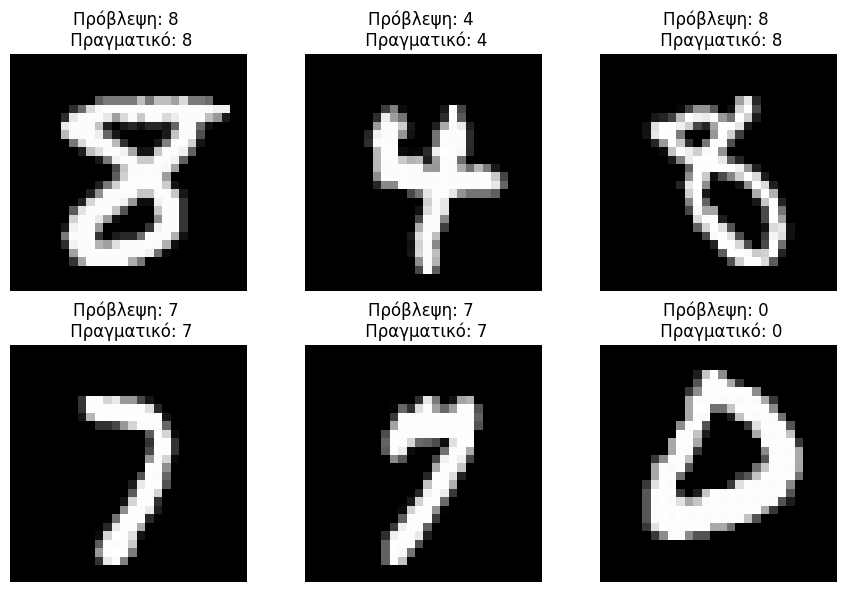

In [ ]:
#y_predict_knn: οι δικές μου προβλέψεις
#y_test: οι πραγματικές ετικέτες
#θέλουμε y_predict_knn==y_test

y_predict_knn_array=np.array(y_predict_knn) # Convert list to array for ease of use
correct=np.where(y_predict_knn_array==y_test)[0] # Indices where prediction matches the true label

figure,axes=plt.subplots(2,3,figsize=(9,6)) # 6 images displayed in 2 rows and 3 columns
axes=axes.flatten()

for i in range(6): # For 6 correct predictions
  index=correct[i]
  image=X_test[index].reshape(28,28) # Reshape the 784-dimensional vector into a 28x28 image

  # Display images
  ax=axes[i]
  ax.imshow(image, cmap='gray')
  ax.set_title(f"Predicted: {y_predict_knn_array[index]} \n Actual: {y_test[index]}")
  ax.axis('off')

plt.tight_layout()
plt.savefig("correct_knn.png", bbox_inches='tight', dpi=300)
plt.show()

---
Examples of Incorrect Classification

---

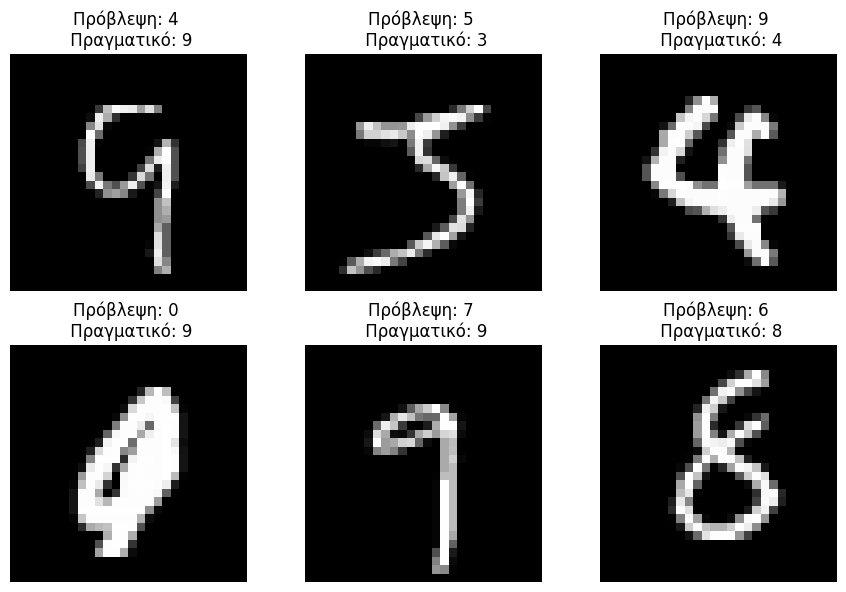

In [ ]:
y_predict_knn_array=np.array(y_predict_knn) # Convert list to array for ease of use
incorrect=np.where(y_predict_knn_array!=y_test)[0] # Indices where prediction does not match the true label

figure,axes=plt.subplots(2,3,figsize=(9,6)) # 6 images displayed in 2 rows and 3 columns
axes=axes.flatten()

for i in range(6): # For 6 incorrect predictions
  index=incorrect[i]
  image=X_test[index].reshape(28,28) # Reshape the 784-dimensional vector into a 28x28 image

  # Display images
  ax=axes[i]
  ax.imshow(image, cmap='gray')
  ax.set_title(f"Predicted: {y_predict_knn_array[index]} \n Actual: {y_test[index]}")
  ax.axis('off')

plt.tight_layout()
plt.savefig("incorrect_knn.png", bbox_inches='tight', dpi=300)
plt.show()

---
Confusion Matrices for k-NN

---




In [ ]:
# Hyperparameters: k=3, k=100, k=2500, k=9000, k=34500, k=60000, Euclidean distance
# Lists to store predictions
y_predict_knn_k3=[] #k=3
y_predict_knn_k100=[] #k=100
y_predict_knn_k2500=[] #k2500
y_predict_knn_k9000=[] #k=9000
y_predict_knn_k34500=[] #k=34500
y_predict_knn_k60000=[] #k=60000

for x in X_test: # For each test image
  distances=np.sqrt(np.sum((X_train-x)**2, axis=1)) # Euclidean distance
  indices=np.argsort(distances) # Sorting indices

  k3_nearest_labels=y_train[indices[:3]] #k=3
  k100_nearest_labels=y_train[indices[:100]] #k=100
  k2500_nearest_labels=y_train[indices[:2500]] #k=2500
  k9000_nearest_labels=y_train[indices[:9000]] #k=9000
  k34500_nearest_labels=y_train[indices[:34500]] #k=34500
  k60000_nearest_labels=y_train[indices[:60000]] #k=60000

  # Most frequent label for each k
  most_common_k3=Counter(k3_nearest_labels).most_common(1)[0][0] #k=3
  most_common_k100=Counter(k100_nearest_labels).most_common(1)[0][0] #k=100
  most_common_k2500=Counter(k2500_nearest_labels).most_common(1)[0][0] #k=2500
  most_common_k9000=Counter(k9000_nearest_labels).most_common(1)[0][0] #k=9000
  most_common_k34500=Counter(k34500_nearest_labels).most_common(1)[0][0] #k=34500
  most_common_k60000=Counter(k60000_nearest_labels).most_common(1)[0][0] #k=60000

  y_predict_knn_k3.append(most_common_k3) #k=3
  y_predict_knn_k100.append(most_common_k100) #k=100
  y_predict_knn_k2500.append(most_common_k2500) #k=2500
  y_predict_knn_k9000.append(most_common_k9000) #k=9000
  y_predict_knn_k34500.append(most_common_k34500) #k=34500
  y_predict_knn_k60000.append(most_common_k60000) #k=60000

# Evaluation
rating_k3=accuracy_score(y_test,y_predict_knn_k3) #k=3
rating_k100=accuracy_score(y_test,y_predict_knn_k100) #k=100
rating_k2500=accuracy_score(y_test,y_predict_knn_k2500) #k=2500
rating_k9000=accuracy_score(y_test,y_predict_knn_k9000) #k=9000
rating_k34500=accuracy_score(y_test,y_predict_knn_k34500) #k=34500
rating_k60000=accuracy_score(y_test,y_predict_knn_k60000) #k=60000

print(f"Accuracy for k=3 (Euclidean): {rating_k3}")
print(f"Accuracy for k=100 (Euclidean): {rating_k100}")
print(f"Accuracy for k=2500 (Euclidean): {rating_k2500}")
print(f"Accuracy for k=9000 (Euclidean): {rating_k9000}")
print(f"Accuracy for k=34500 (Euclidean): {rating_k34500}")
print(f"Accuracy for k=60000 (Euclidean): {rating_k60000}")

Αξιολόγηση για k=3: 0.973
Αξιολόγηση για k=100: 0.9377
Αξιολόγηση για k=2500: 0.8024
Αξιολόγηση για k=9000: 0.6514
Αιξιολόγηση για k=34500: 0.3195
Αξιολόγηση για k=60000: 0.1152


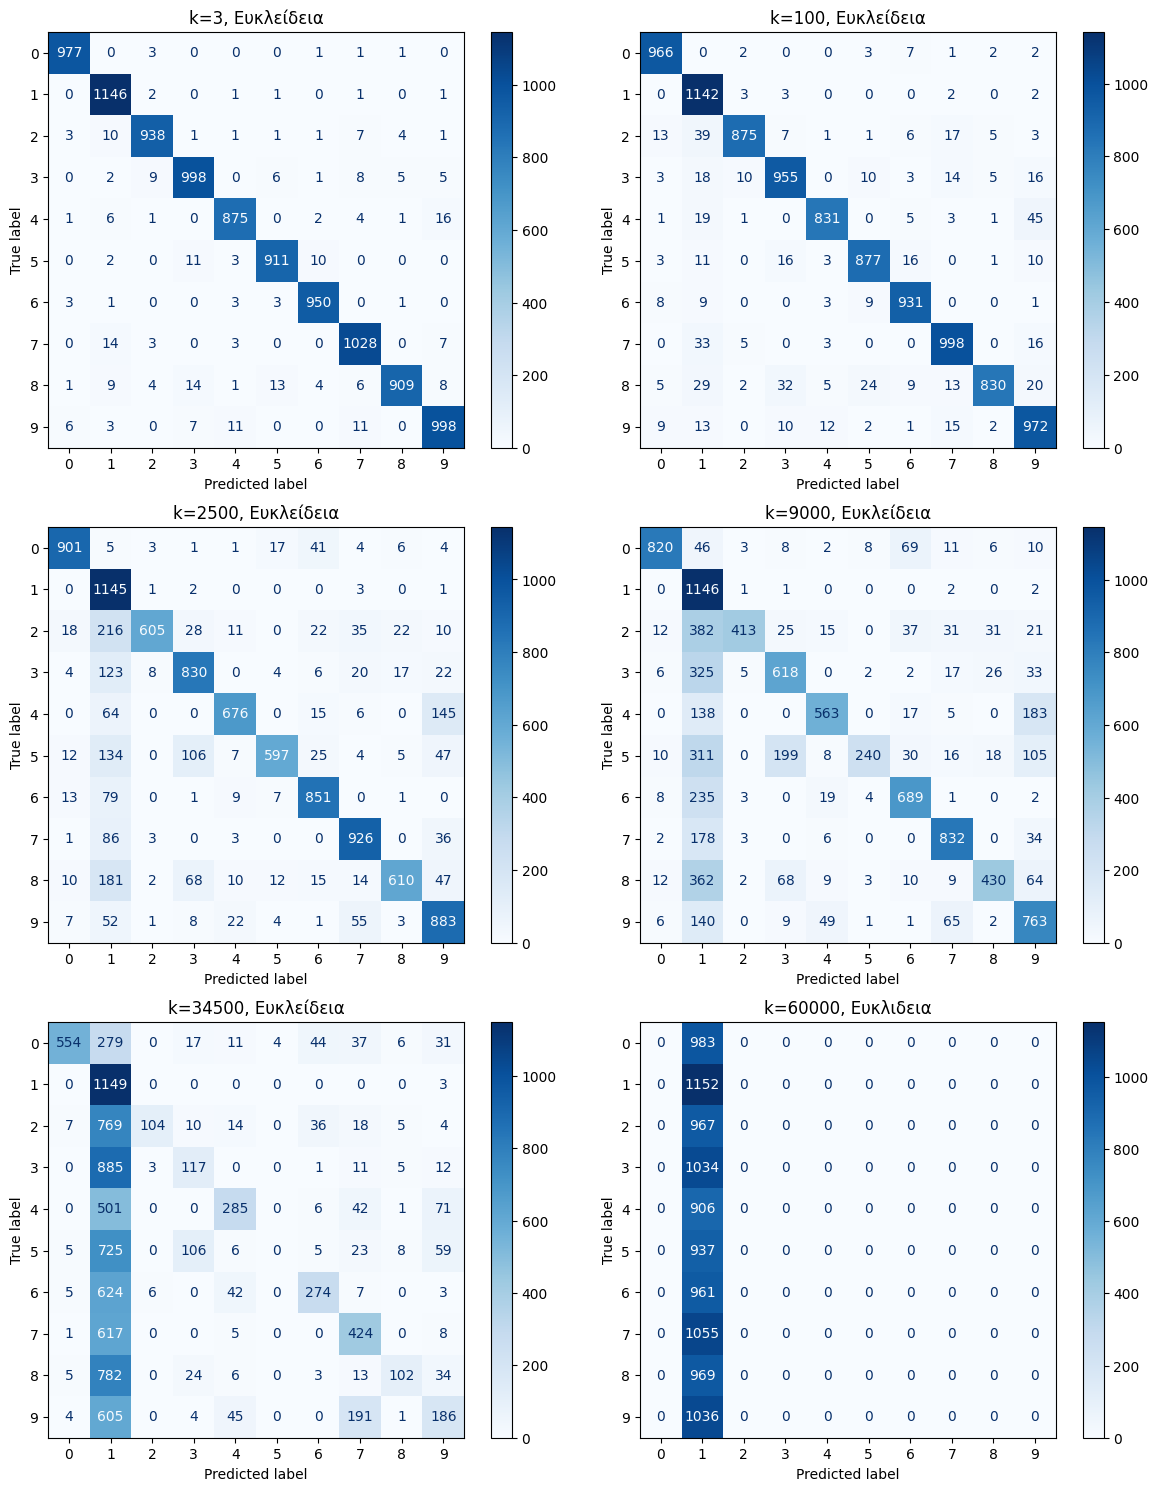

In [ ]:
#πίνακες σύγχυσης για Ευκλείδεια απόσταση
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrices for Euclidean distance
cm_eucl_k3=confusion_matrix(y_test, y_predict_knn_k3) #k=3
cm_eucl_k100=confusion_matrix(y_test, y_predict_knn_k100) #k=100
cm_eucl_k2500=confusion_matrix(y_test, y_predict_knn_k2500) #k=2500
cm_eucl_k9000=confusion_matrix(y_test, y_predict_knn_k9000) #k=9000
cm_eucl_k34500=confusion_matrix(y_test, y_predict_knn_k34500) #k=34500
cm_eucl_k60000=confusion_matrix(y_test, y_predict_knn_k60000) #k=60000

figure,axes=plt.subplots(3,2,figsize=(12,15)) #3 γραμμές, 2 στήλες

eucl_k3=ConfusionMatrixDisplay(confusion_matrix=cm_eucl_k3) #k=3
eucl_k100=ConfusionMatrixDisplay(confusion_matrix=cm_eucl_k100) #k=100
eucl_k2500=ConfusionMatrixDisplay(confusion_matrix=cm_eucl_k2500) #k=2500
eucl_k9000=ConfusionMatrixDisplay(confusion_matrix=cm_eucl_k9000) #k=9000
eucl_k34500=ConfusionMatrixDisplay(confusion_matrix=cm_eucl_k34500) #k=34500
eucl_k60000=ConfusionMatrixDisplay(confusion_matrix=cm_eucl_k60000) #k=60000

eucl_k3.plot(cmap='Blues', ax=axes[0,0], values_format='d')
axes[0,0].set_title("k=3, Euclidean")
eucl_k100.plot(cmap='Blues', ax=axes[0,1], values_format='d')
axes[0,1].set_title("k=100, Euclidean")
eucl_k2500.plot(cmap='Blues', ax=axes[1,0], values_format='d')
axes[1,0].set_title("k=2500, Euclidean")
eucl_k9000.plot(cmap='Blues', ax=axes[1,1], values_format='d')
axes[1,1].set_title("k=9000, Euclidean")
eucl_k34500.plot(cmap='Blues', ax=axes[2,0], values_format='d')
axes[2,0].set_title("k=34500, Euclidean")
eucl_k60000.plot(cmap='Blues', ax=axes[2,1], values_format='d')
axes[2,1].set_title("k=60000, Euclidean")

plt.tight_layout()
plt.savefig("matrix_euclidean.png", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Hyperparameters: k=3, k=100, k=2500, k=9000, k=34500, k=60000, Manhattan distance
# Lists to store predictions
y_predict_knn_k3=[] #k=3
y_predict_knn_k100=[] #k=100
y_predict_knn_k2500=[] #k=2500
y_predict_knn_k9000=[] #k=9000
y_predict_knn_k34500=[] #k=34500
y_predict_knn_k60000=[] #k=60000

for x in X_test: # For each test image
  distances = np.sum(np.abs(X_train - x), axis=1) # Manhattan distance
  indices=np.argsort(distances) # Sorting indices

  k3_nearest_labels=y_train[indices[:3]] #k=3
  k100_nearest_labels=y_train[indices[:100]] #k=100
  k2500_nearest_labels=y_train[indices[:2500]] #k=2500
  k9000_nearest_labels=y_train[indices[:9000]] #k=9000
  k34500_nearest_labels=y_train[indices[:34500]] #k=34500
  k60000_nearest_labels=y_train[indices[:60000]] #k=60000

  # Most frequent label for each k
  most_common_k3=Counter(k3_nearest_labels).most_common(1)[0][0] #k=3
  most_common_k100=Counter(k100_nearest_labels).most_common(1)[0][0] #k=100
  most_common_k2500=Counter(k2500_nearest_labels).most_common(1)[0][0] #k=2500
  most_common_k9000=Counter(k9000_nearest_labels).most_common(1)[0][0] #k=9000
  most_common_k34500=Counter(k34500_nearest_labels).most_common(1)[0][0] #k=34500
  most_common_k60000=Counter(k60000_nearest_labels).most_common(1)[0][0] #k=60000

  y_predict_knn_k3.append(most_common_k3) #k=3
  y_predict_knn_k100.append(most_common_k100) #k=100
  y_predict_knn_k2500.append(most_common_k2500) #k=2500
  y_predict_knn_k9000.append(most_common_k9000) #k=9000
  y_predict_knn_k34500.append(most_common_k34500) #k=34500
  y_predict_knn_k60000.append(most_common_k60000) #k=60000

# Evaluation
rating_k3=accuracy_score(y_test,y_predict_knn_k3) #k=3
rating_k100=accuracy_score(y_test,y_predict_knn_k100) #k=100
rating_k2500=accuracy_score(y_test,y_predict_knn_k2500) #k=2500
rating_k9000=accuracy_score(y_test,y_predict_knn_k9000) #k=9000
rating_k34500=accuracy_score(y_test,y_predict_knn_k34500) #k=34500
rating_k60000=accuracy_score(y_test,y_predict_knn_k60000) #k=60000

print(f"Accuracy for k=3 (Manhattan): {rating_k3}")
print(f"Accuracy for k=100 (Manhattan): {rating_k100}")
print(f"Accuracy for k=2500 (Manhattan): {rating_k2500}")
print(f"Accuracy for k=9000 (Manhattan): {rating_k9000}")
print(f"Accuracy for k=34500 (Manhattan): {rating_k34500}")
print(f"Accuracy for k=60000 (Manhattan): {rating_k60000}")

Αξιολόγηση για k=3: 0.9659
Αξιολόγηση για k=100: 0.9287
Αξιολόγηση για k=2500: 0.7686
Αξιολόγηση για k=9000: 0.5918
Αξιολόγηση για k=34500: 0.2563
Αξιολόγηση για k=60000: 0.1152


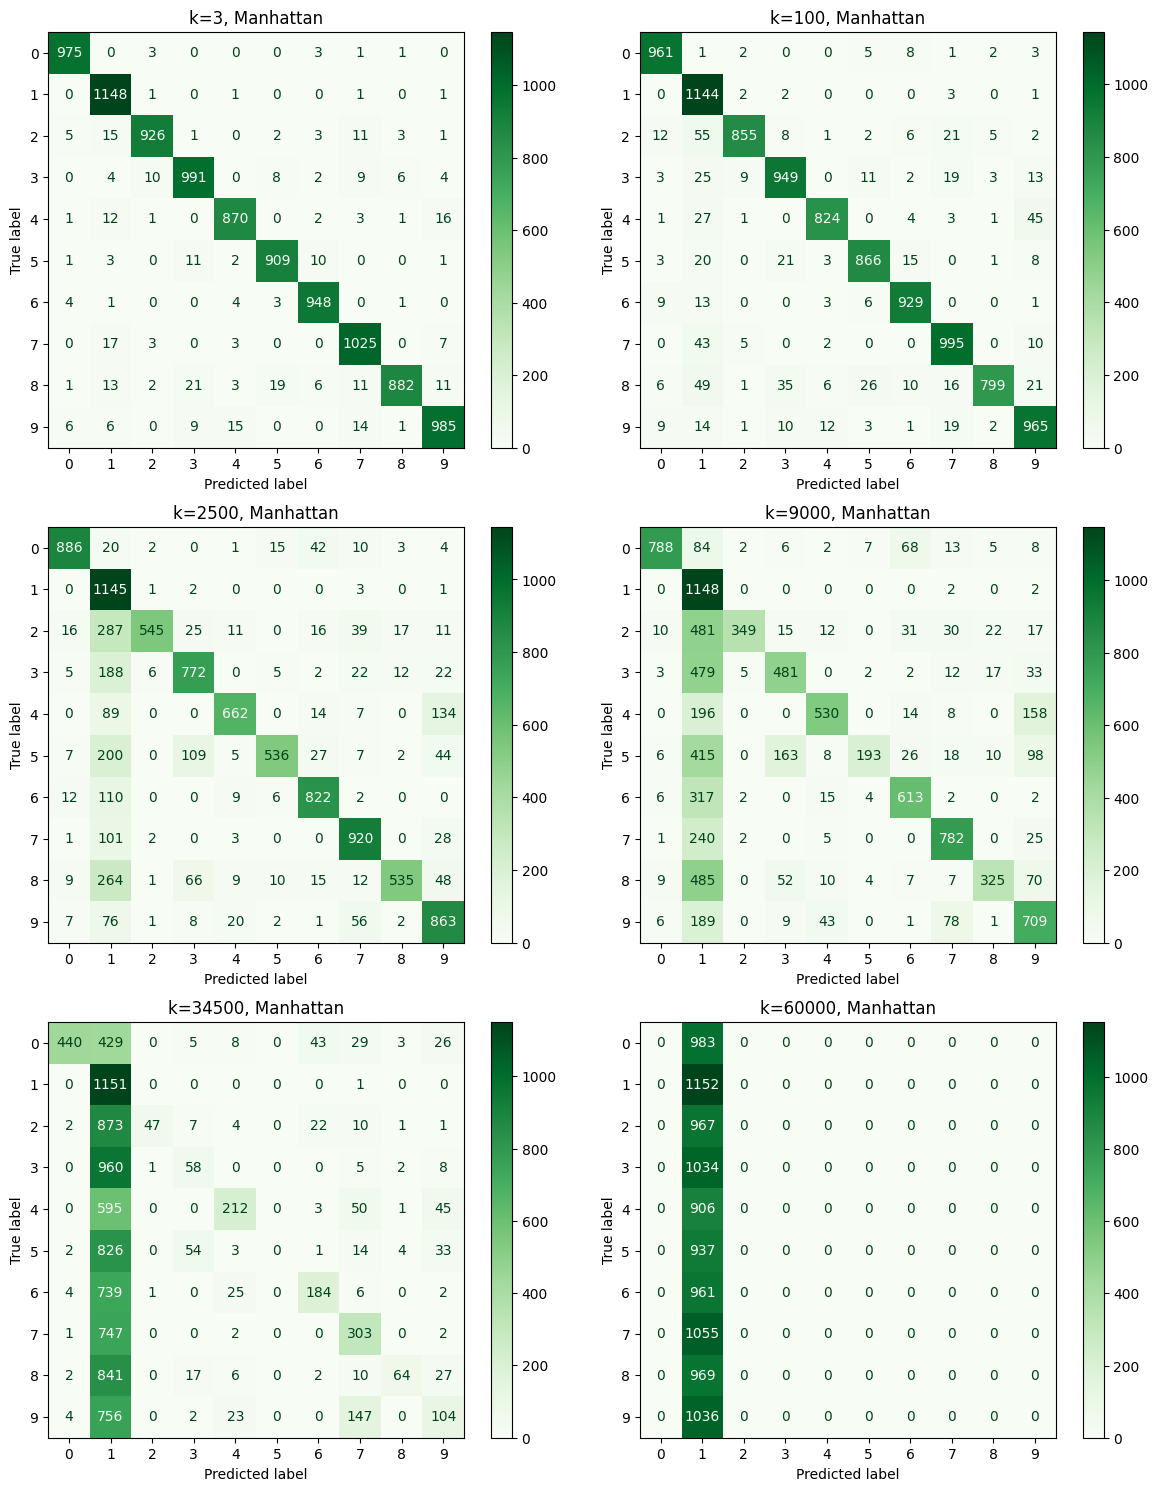

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrices for Manhattan distance
cm_man_k3=confusion_matrix(y_test, y_predict_knn_k3) #k=3
cm_man_k100=confusion_matrix(y_test, y_predict_knn_k100) #k=100
cm_man_k2500=confusion_matrix(y_test, y_predict_knn_k2500) #k=2500
cm_man_k9000=confusion_matrix(y_test, y_predict_knn_k9000) #k=9000
cm_man_k34500=confusion_matrix(y_test, y_predict_knn_k34500) #k=34500
cm_man_k60000=confusion_matrix(y_test, y_predict_knn_k60000) #k=60000

figure,axes=plt.subplots(3,2,figsize=(12,15))

man_k3=ConfusionMatrixDisplay(confusion_matrix=cm_man_k3) #k=3
man_k100=ConfusionMatrixDisplay(confusion_matrix=cm_man_k100) #k=100
man_k2500=ConfusionMatrixDisplay(confusion_matrix=cm_man_k2500) #k=2500
man_k9000=ConfusionMatrixDisplay(confusion_matrix=cm_man_k9000) #k=9000
man_k34500=ConfusionMatrixDisplay(confusion_matrix=cm_man_k34500) #k=34500
man_k60000=ConfusionMatrixDisplay(confusion_matrix=cm_man_k60000) #k=60000

man_k3.plot(cmap='Greens', ax=axes[0,0], values_format='d')
axes[0,0].set_title("k=3, Manhattan")
man_k100.plot(cmap='Greens', ax=axes[0,1], values_format='d')
axes[0,1].set_title("k=100, Manhattan")
man_k2500.plot(cmap='Greens', ax=axes[1,0], values_format='d')
axes[1,0].set_title("k=2500, Manhattan")
man_k9000.plot(cmap='Greens', ax=axes[1,1], values_format='d')
axes[1,1].set_title("k=9000, Manhattan")
man_k34500.plot(cmap='Greens', ax=axes[2,0], values_format='d')
axes[2,0].set_title("k=34500, Manhattan")
man_k60000.plot(cmap='Greens', ax=axes[2,1], values_format='d')
axes[2,1].set_title("k=60000, Manhattan")

plt.tight_layout()
plt.savefig("matrix_manhattan.png", bbox_inches='tight', dpi=300)
plt.show()

# **Nearest Centroid Classifier**

The algorithm takes all training images belonging to each digit and computes their center (centroid). When given a new, unknown image from X_test, it measures its distance to these 10 centroids and classifies it into the class with the closest center.

---
Scikit-learn implementation for verification

---



In [ ]:
nc_model=NearestCentroid() # Model creation
nc_model.fit(X_train,y_train) # Training
y_predict_nc=nc_model.predict(X_test) # Prediction
rating=accuracy_score(y_test,y_predict_nc) # Evaluation
print(f"Scikit-learn Nearest Centroid Accuracy: {rating}")

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_nearest_centroid.py:244: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(


Αξιολόγηση: 0.813


---
Custom implementation from scratch

---


In [ ]:
centroids={} # Dictionary to store the 10 centroids (using mean for Euclidean)

for c in np.unique(y_train): # For each class
  class_images=X_train[y_train==c] # Images belonging to class c
  centroids[c]=np.mean(class_images, axis=0) # Mean vector

# Finding the nearest centroid
y_predict_nc=[] # List to store predictions
for x in X_test: # For each test image
  distances=[] # List containing the distances of image x from each center
  for c in centroids: # For each center
    dist=np.sqrt(np.sum((x-centroids[c])**2)) # Euclidean distance
    distances.append((dist,c)) # Append distance and class label
  best_dist, best_class=min(distances) # Keep the minimum distance and its corresponding class
  y_predict_nc.append(best_class)

# Evaluation
rating=accuracy_score(y_test,y_predict_nc)
print(f"Custom Nearest Centroid Accuracy: {rating}")

Αξιολόγηση: 0.813


---
Examples of Correct Classification

---

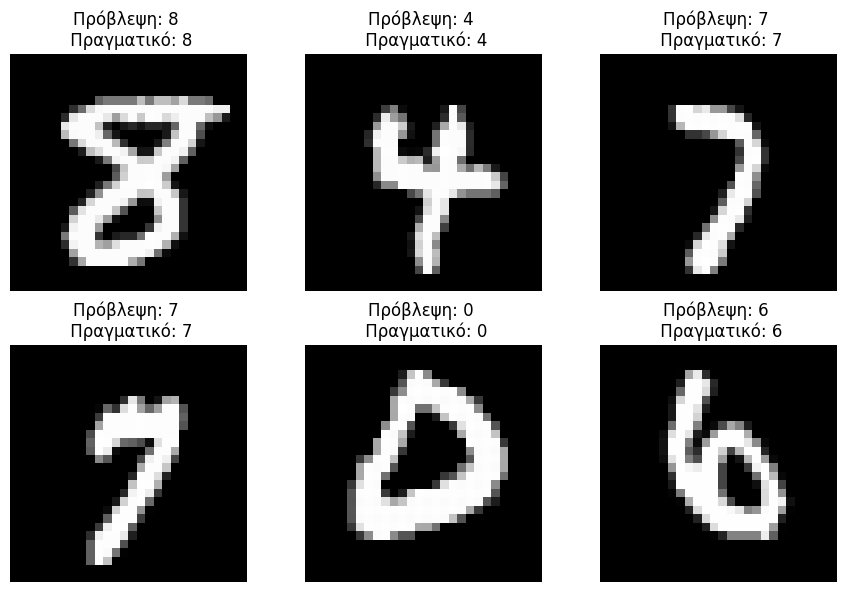

In [ ]:
y_predict_nc_array=np.array(y_predict_nc) # Convert list to array for ease of use
correct=np.where(y_predict_nc_array==y_test)[0] # Indices where prediction matches the true label

figure,axes=plt.subplots(2,3,figsize=(9,6)) # 6 images displayed in 2 rows and 3 columns
axes=axes.flatten()

for i in range(6): # For 6 correct predictions
  index=correct[i]
  image=X_test[index].reshape(28,28) # Reshape into a 28x28 image

  # Display images
  ax=axes[i]
  ax.imshow(image, cmap='gray')
  ax.set_title(f"Predicted: {y_predict_nc_array[index]} \n Actual: {y_test[index]}")
  ax.axis('off')

plt.tight_layout()
plt.savefig("correct_nc.png", bbox_inches='tight', dpi=300)
plt.show()

---
Examples of Incorrect Classification

------

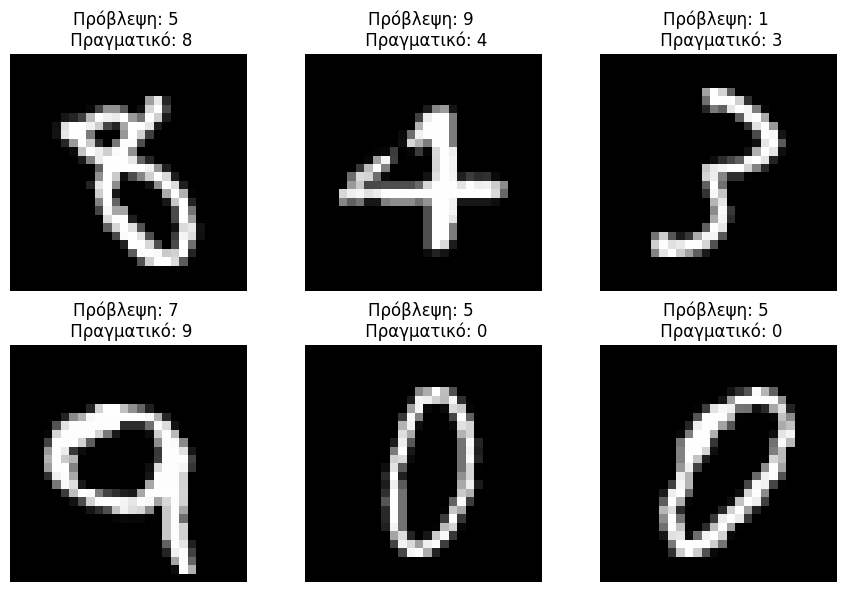

In [ ]:
y_predict_nc_array=np.array(y_predict_nc) # Convert list to array for ease of use
incorrect=np.where(y_predict_nc_array!=y_test)[0] # Indices where prediction does not match the true label

figure,axes=plt.subplots(2,3,figsize=(9,6)) # 6 images displayed in 2 rows and 3 columns
axes=axes.flatten()

for i in range(6): # For 6 incorrect predictions
  index=incorrect[i]
  image=X_test[index].reshape(28,28) # Reshape into a 28x28 image

  # Display images
  ax=axes[i]
  ax.imshow(image, cmap='gray')
  ax.set_title(f"Predicted: {y_predict_nc_array[index]} \n Actual: {y_test[index]}")
  ax.axis('off')

plt.tight_layout()
plt.savefig("incorrect_nc.png", bbox_inches='tight', dpi=300)
plt.show()

---
Confusion Matrices for Nearest Centroid

---




In [ ]:
centroids={} # save the 10 centroids

for c in np.unique(y_train): # for each class
  class_images=X_train[y_train==c] # images class c
  centroids[c]=np.mean(class_images, axis=0) # mean

# Finding the nearest centroid for both distance metrics
y_predict_eucl_nc=[] # Euclidean distance predictions
y_predict_man_nc=[] # Manhattan distance predictions
for x in X_test: # For each test image
  distances_eucl=[]
  distances_man=[]

  for c in centroids: # For each centroid
    dist_eucl=np.sqrt(np.sum((x-centroids[c])**2)) # Euclidean distance measured from the mean centroid
    dist_man=np.sum(np.abs(x-centroids[c])) # Manhattan distance measured from the median centroid

    # Add distance and centroid
    distances_eucl.append((dist_eucl,c))
    distances_man.append((dist_man,c))

  # Select the minimum distance and class label
  best_dist_eucl, best_class_eucl=min(distances_eucl)
  y_predict_eucl_nc.append(best_class_eucl)

  best_dist_man, best_class_man=min(distances_man)
  y_predict_man_nc.append(best_class_man)

# Evaluation
rating_eucl=accuracy_score(y_test,y_predict_eucl_nc)
rating_man=accuracy_score(y_test,y_predict_man_nc)
print(f"Nearest Centroid Euclidean Distance Accuracy: {rating_eucl}")
print(f"Nearest Centroid Manhattan Distance Accuracy: {rating_man}")

Αξιολόγηση Ευκλείδειας απόστασης: 0.813
Αξιολόγηση απόστασης Manhattan: 0.6576


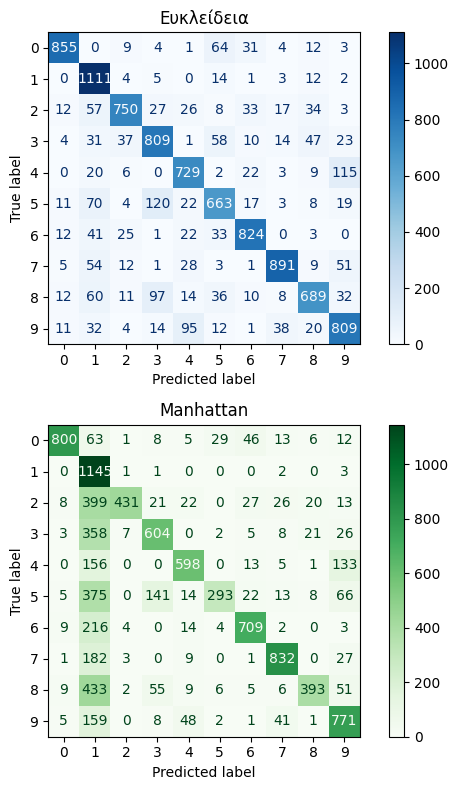

In [ ]:
# Confusion matrices
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#λίστες προβλέψεων
cm_eucl=confusion_matrix(y_test, y_predict_eucl_nc) # Euclidean
cm_man=confusion_matrix(y_test, y_predict_man_nc) # Manhattan

figure,axes=plt.subplots(2,1,figsize=(6,8)) # 2 rows, 1 column

eucl=ConfusionMatrixDisplay(confusion_matrix=cm_eucl)
man=ConfusionMatrixDisplay(confusion_matrix=cm_man)

eucl.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title("Euclidean")
man.plot(cmap='Greens', ax=axes[1], values_format='d')
axes[1].set_title("Manhattan")

plt.tight_layout()
plt.savefig("matrix_nc.png", bbox_inches='tight', dpi=300)
plt.show()